# **Project Name**
## Uber Supply Demand Gap

##### **Project Type** - EDA  
##### **Contribution** - Individual  
##### **Name** - Kursam Durga Kalyan

# **Project Summary -**

This project performs an exploratory data analysis of Uber request data to understand the major reasons why customer ride requests are not successfully completed and to identify the operational periods where the service experiences the greatest imbalance between demand and available drivers. The dataset contains 6,745 ride requests made between 11 July 2016 and 15 July 2016, with information on request ID, pickup point, driver ID, request time, drop time and request status.

The analysis starts by checking the structure, data types, duplicates and missing values. Missing Driver ID values are expected for requests that did not result in an assigned driver, while missing Drop timestamps occur for trips that were cancelled or had no cars available. Request timestamps are converted into datetime format so that hour, day and weekday patterns can be studied. Trip duration is calculated for completed rides, and additional categorical indicators are created to distinguish completed and unfulfilled requests.

The most important finding is that only 2,831 of the 6,745 requests were completed, giving an overall completion rate of about 42%. The remaining 58% were unsuccessful: 2,650 requests (39.3%) had no cars available and 1,264 requests (18.7%) were cancelled. Therefore, the largest operational problem is not customer cancellation but the inability to supply a car when requested.

The problem is strongly time- and location-dependent. Airport requests show a major concentration of “No Cars Available” outcomes, especially during the evening hours from approximately 17:00 to 21:00. In contrast, City requests show a much stronger concentration of cancellations during the morning commute, particularly around 5:00 to 9:00. This creates two distinct demand-supply pressure periods: evening demand from the Airport to the City and morning demand from the City to the Airport. The pickup-point analysis also shows that Airport requests have 1,713 “No Cars Available” outcomes, compared with 937 from the City.

Completed trips have an average duration of approximately 52.4 minutes, with most completed trips falling between roughly 41 and 64 minutes. The distribution and time-based analysis indicate that operational capacity should be aligned with predictable commuter flows rather than distributed uniformly throughout the day.

Based on these findings, the recommended business response is to improve driver availability during the high-demand Airport evening window, introduce incentives or scheduled driver positioning before demand peaks, and create stronger supply coverage for City-to-Airport trips in the early morning. Monitoring cancellation and no-car rates separately is important because the two outcomes require different interventions. These actions can increase the proportion of completed requests, improve customer experience, and use the existing driver fleet more efficiently.

# **GitHub Link**

https://github.com/durgakalyankursam/Uber_Supply_Demand_Gap_EDA

# **Problem Statement**



**Analyze Uber ride-request data to identify patterns in request demand, trip completion, customer cancellations, and driver unavailability, with special focus on time of day and pickup location. The objective is to determine the major causes of unsuccessful requests and recommend operational actions that can improve the ride completion rate.**

#### **Define Your Business Objective?**

The business objective is to increase the percentage of ride requests that are successfully completed by identifying when and where demand exceeds available driver supply, while separately understanding customer cancellations. The analysis should help Uber improve driver allocation, reduce “No Cars Available” requests, reduce avoidable cancellations, and improve the customer experience during peak demand periods.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Dataset Loading

In [2]:
# Load Dataset
uber = pd.read_csv("Uber Request Data.csv")

uber.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.00,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.00,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.00,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.00,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.00,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset First View

In [3]:
# Dataset First Look
display(uber.head())
display(uber.tail())

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.00,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.00,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.00,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.00,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.00,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN
6744,6753,Airport,NaN,No Cars Available,15-07-2016 23:55:03,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
rows, columns = uber.shape
print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 6,745
Number of columns: 6


### Dataset Information

In [5]:
# Dataset Info
uber.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 608.1 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = uber.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = uber.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(uber) * 100).round(2)
missing_table = pd.DataFrame({"Missing Values": missing, "Missing %": missing_pct})
display(missing_table)

,Missing Values,Missing %
Drop timestamp,3914,58.03
Driver id,2650,39.29
Pickup point,0,0.00
Request id,0,0.00
Status,0,0.00
Request timestamp,0,0.00


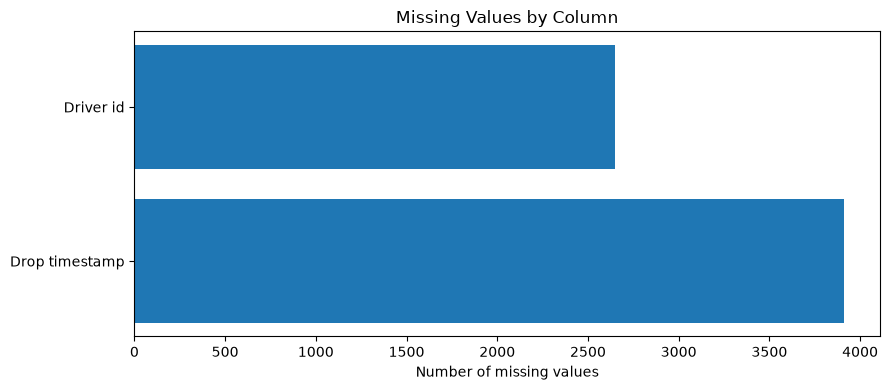

In [8]:
# Visualizing the missing values
plt.figure(figsize=(9, 4))
missing_nonzero = missing[missing > 0]
plt.barh(missing_nonzero.index, missing_nonzero.values)
plt.title("Missing Values by Column")
plt.xlabel("Number of missing values")
plt.ylabel("")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The dataset contains **6,745 requests and 6 variables**.
- There are **no duplicate rows**.
- `Driver id` has 2,650 missing values. These correspond exactly to the requests with **No Cars Available**, so the missingness is operationally meaningful rather than a random data-entry issue.
- `Drop timestamp` has 3,914 missing values. These correspond to requests that were **Cancelled** or had **No Cars Available**, because no completed trip ended with a drop timestamp in those records.
- The three request outcomes are **Trip Completed (2,831)**, **No Cars Available (2,650)** and **Cancelled (1,264)**.
- Requests are split between two pickup locations: **City (3,507)** and **Airport (3,238)**.
- The request period covers **11 July 2016 through 15 July 2016**, allowing analysis by hour and day.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(uber.columns.tolist())

['Request id', 'Pickup point', 'Driver id', 'Status', 'Request timestamp', 'Drop timestamp']


In [10]:
# Dataset Describe
display(uber.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Request id,"6,745.00",NaN,NaN,NaN,"3,384.64","1,955.10",1.00,"1,691.00","3,387.00","5,080.00","6,766.00"
Pickup point,6745,2,City,3507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver id,"4,095.00",NaN,NaN,NaN,149.50,86.05,1.00,75.00,149.00,224.00,300.00
Status,6745,3,Trip Completed,2831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Request timestamp,6745,5618,11/7/2016 17:57,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drop timestamp,2831,2598,11/7/2016 13:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

Variable  ----------------    Description 

1. Request id-----------------Unique identifier for each Uber request.
2. Pickup point---------------Location from which the ride was requested: City or Airport.
3. Driver id -----------------Identifier of the driver assigned to the request; missing when no driver was assigned.
4. Status---------------------Outcome of the request: Trip Completed, Cancelled, or No Cars Available.
5. Request timestamp----------Date and time when the ride was requested.
6. Drop timestamp-------------Date and time when a completed ride ended; missing for unsuccessful requests.

For analysis, the request timestamp is converted to a datetime field, and hour/day features are derived. Trip duration is calculated only for completed trips.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable
for col in uber.columns:
    print(f"\n{col}:")
    print(f"  Unique values: {uber[col].nunique(dropna=True)}")
    if uber[col].nunique(dropna=True) <= 20:
        print(f"  Values: {uber[col].dropna().unique().tolist()}")


Request id:
  Unique values: 6745

Pickup point:
  Unique values: 2
  Values: ['Airport', 'City']

Driver id:
  Unique values: 300

Status:
  Unique values: 3
  Values: ['Trip Completed', 'Cancelled', 'No Cars Available']

Request timestamp:
  Unique values: 5618

Drop timestamp:
  Unique values: 2598


## 3. ***Data Wrangling***

### Data Wrangling Code

In [20]:
# Data Wrangling Code

df = uber.copy()

# Convert timestamps automatically
df["Request datetime"] = pd.to_datetime(
    df["Request timestamp"],
    dayfirst=True,
    errors="coerce"
)

df["Drop datetime"] = pd.to_datetime(
    df["Drop timestamp"],
    dayfirst=True,
    errors="coerce"
)

# Check for any dates that could not be converted
print("Invalid Request timestamps:",
      df["Request datetime"].isna().sum())

print("Invalid Drop timestamps:",
      df["Drop datetime"].isna().sum())

# Extract time-related features
df["Request hour"] = df["Request datetime"].dt.hour
df["Request day"] = df["Request datetime"].dt.day
df["Weekday"] = df["Request datetime"].dt.day_name()
df["Day number"] = df["Request datetime"].dt.dayofweek

# Create completion indicator
df["Completed"] = (
    df["Status"] == "Trip Completed"
).astype(int)

# Create unfulfilled indicator
df["Unfulfilled"] = (
    df["Status"] != "Trip Completed"
).astype(int)

# Calculate trip duration in minutes
df["Trip duration (min)"] = (
    df["Drop datetime"] - df["Request datetime"]
).dt.total_seconds() / 60

print("\nData wrangling completed successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Invalid Request timestamps: 4071
Invalid Drop timestamps: 5595

Data wrangling completed successfully.
Rows: 6745
Columns: 15


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request datetime,Drop datetime,Request hour,Request day,Weekday,Day number,Completed,Unfulfilled,Trip duration (min)
0,619,Airport,1.00,Trip Completed,11/7/2016 11:51,11/7/2016 13:00,2016-07-11 11:51:00,2016-07-11 13:00:00,11.00,11.00,Monday,0.00,1,0,69.00
1,867,Airport,1.00,Trip Completed,11/7/2016 17:57,11/7/2016 18:47,2016-07-11 17:57:00,2016-07-11 18:47:00,17.00,11.00,Monday,0.00,1,0,50.00
2,1807,City,1.00,Trip Completed,12/7/2016 9:17,12/7/2016 9:58,2016-07-12 09:17:00,2016-07-12 09:58:00,9.00,12.00,Tuesday,1.00,1,0,41.00
3,2532,Airport,1.00,Trip Completed,12/7/2016 21:08,12/7/2016 22:03,2016-07-12 21:08:00,2016-07-12 22:03:00,21.00,12.00,Tuesday,1.00,1,0,55.00
4,3112,City,1.00,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47,NaT,NaT,NaN,NaN,NaN,NaN,1,0,NaN


### What all manipulations have you done and insights you found?

1. Converted request and drop timestamps to datetime format.
2. Extracted request hour, calendar day, weekday and day number to support temporal analysis.
3. Created a `Completed` flag and an `Unfulfilled` flag for business-oriented analysis.
4. Calculated trip duration in minutes for completed rides; unsuccessful requests naturally remain null.
5. Retained missing Driver IDs and Drop timestamps because they carry business meaning rather than being ordinary data-quality errors.
6. The data shows a strong operational imbalance: **39.3% of all requests had no cars available**, while **18.7% were cancelled**. This indicates that driver availability is the largest contributor to lost requests.
7. The pattern varies by pickup point and time: Airport requests are particularly affected by evening driver shortages, while City requests show substantial morning cancellations.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

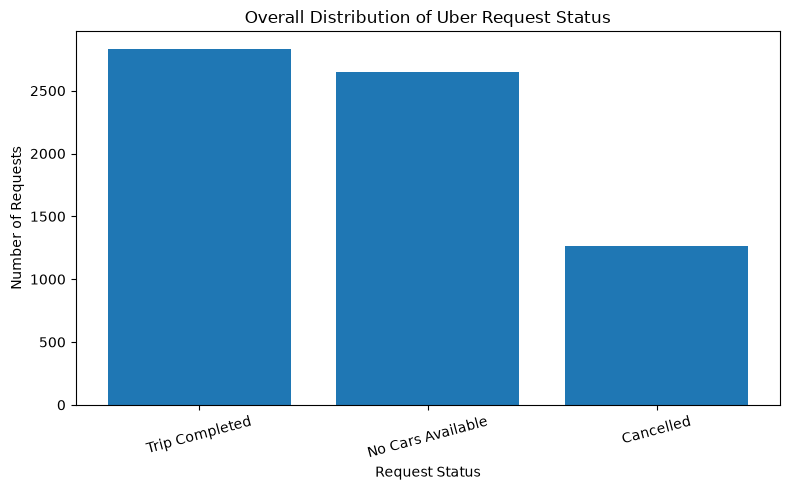

In [21]:
# Chart - 1: Overall request status
status_counts = df["Status"].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values)
plt.title("Overall Distribution of Uber Request Status")
plt.xlabel("Request Status")
plt.ylabel("Number of Requests")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot directly compares the volume of each request outcome.

##### 2. What is/are the insight(s) found from the chart?

Only 2,831 requests were completed, while 2,650 had no cars available and 1,264 were cancelled. The unsuccessful requests (3,914) exceed completed requests (2,831), so service reliability is the main business concern.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Reducing the largest failure category—No Cars Available—offers the biggest opportunity to increase completed trips and revenue.

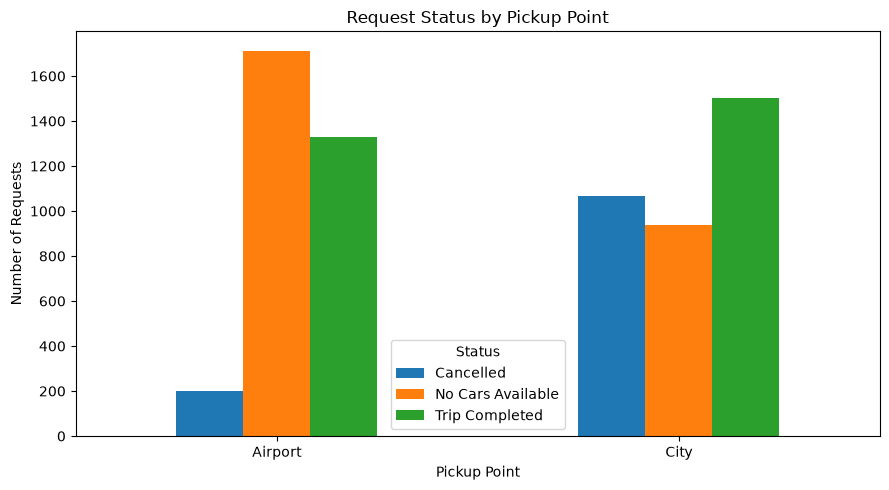

In [22]:
# Chart - 2: Pickup point vs status
pivot = pd.crosstab(df["Pickup point"], df["Status"])
ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Request Status by Pickup Point")
ax.set_xlabel("Pickup Point")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing status by pickup point reveals whether operational problems are concentrated at the Airport or City.

##### 2. What is/are the insight(s) found from the chart?

Airport requests have 1,713 No Cars Available outcomes, far above the City's 937. City requests have more cancellations (1,066 versus 198 at the Airport).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The two locations need different interventions: improve driver supply at the Airport, while reducing friction and improving early-morning City-to-Airport availability to address cancellations.

#### Chart - 3

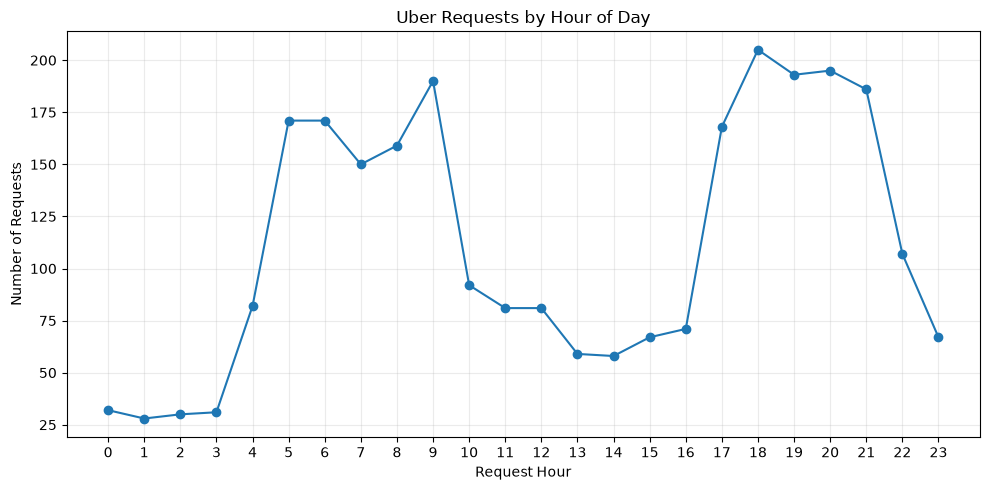

In [23]:
# Chart - 3: Requests by hour
hour_counts = df.groupby('Request hour').size()
plt.figure(figsize=(10, 5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.title("Uber Requests by Hour of Day")
plt.xlabel("Request Hour")
plt.ylabel("Number of Requests")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A time-series style line chart makes demand peaks and low-demand periods easy to identify.

##### 2. What is/are the insight(s) found from the chart?

Demand is strongly concentrated around commuting periods. City demand rises sharply in the early morning, while Airport demand becomes much stronger in the late afternoon and evening.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Driver allocation should be dynamic and scheduled around predictable demand peaks rather than spread evenly across all hours.

#### Chart - 4

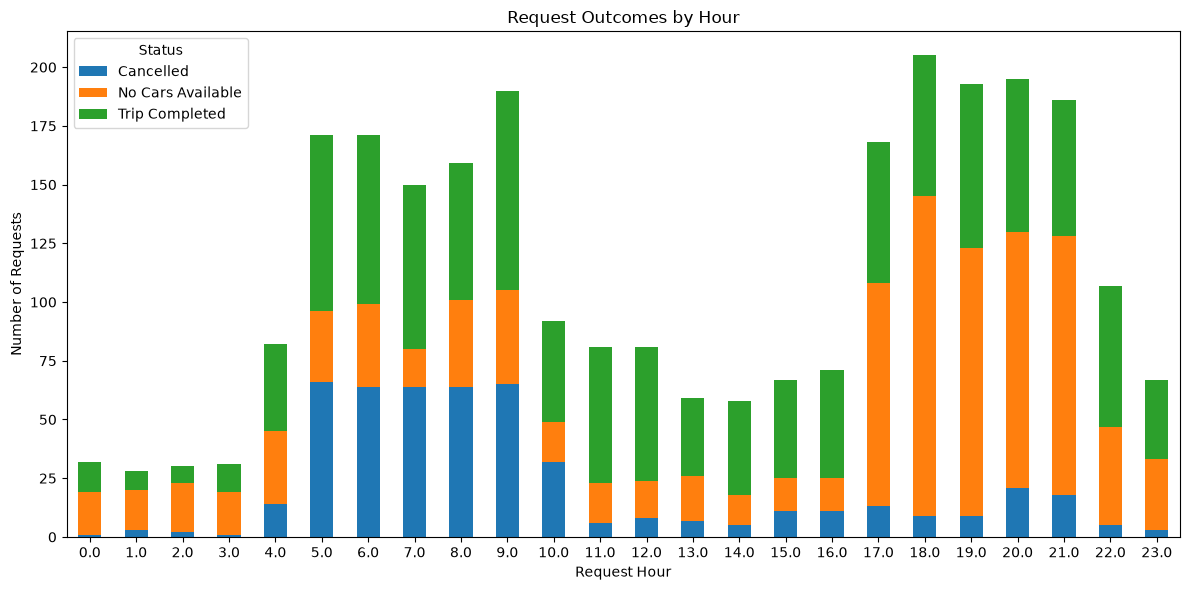

In [24]:
# Chart - 4: Status by hour
hour_status = pd.crosstab(df["Request hour"], df["Status"])
ax = hour_status.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Request Outcomes by Hour")
ax.set_xlabel("Request Hour")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart shows both total demand and the composition of outcomes at each hour.

##### 2. What is/are the insight(s) found from the chart?

No Cars Available increases sharply from about 17:00 through 21:00. Morning hours also show a high number of cancellations, especially around 5:00–9:00.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

These are the most important intervention windows. Peak-hour supply planning can target the exact hours where failed requests rise instead of applying a uniform fleet policy.

#### Chart - 5

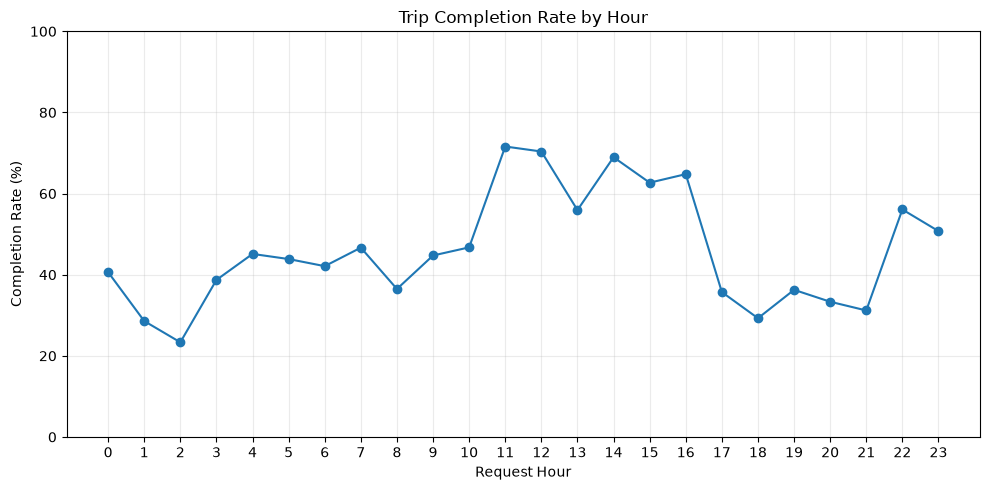

In [25]:
# Chart - 5: Completion rate by hour
hour_completion = df.groupby("Request hour")["Completed"].mean() * 100
plt.figure(figsize=(10, 5))
plt.plot(hour_completion.index, hour_completion.values, marker="o")
plt.title("Trip Completion Rate by Hour")
plt.xlabel("Request Hour")
plt.ylabel("Completion Rate (%)")
plt.xticks(range(24))
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Completion rate normalizes request volumes and shows service quality rather than just demand.

##### 2. What is/are the insight(s) found from the chart?

Completion rates are highest around the middle of the day and fall substantially during the evening peak. The rate is about 32% at 18:00 and about 32% at 21:00, compared with above 65% around 11:00–12:00.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

The sharp evening decline confirms that capacity is not keeping pace with demand. Incentives or pre-positioning should focus on these low-completion hours.

#### Chart - 6

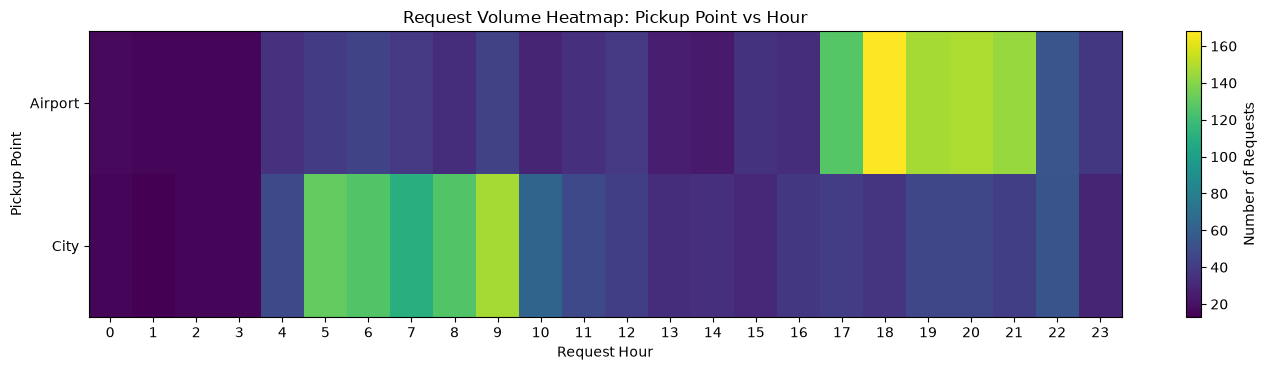

In [26]:
# Chart - 6: Pickup point and hour heatmap
pivot = pd.crosstab(df["Pickup point"], df["Request hour"])
plt.figure(figsize=(14, 3.8))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Number of Requests")
plt.title("Request Volume Heatmap: Pickup Point vs Hour")
plt.xlabel("Request Hour")
plt.ylabel("Pickup Point")
plt.xticks(range(24), range(24))
plt.yticks(range(len(pivot.index)), pivot.index)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap makes the contrast between City and Airport demand across the 24-hour day visually obvious.

##### 2. What is/are the insight(s) found from the chart?

City demand is concentrated in the early morning, while Airport demand is much stronger in the late afternoon and evening. This indicates directional commuter flows.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Driver repositioning can be planned around these directional flows—for example, increasing Airport supply before the evening peak and City supply before the morning Airport commute.

#### Chart - 7

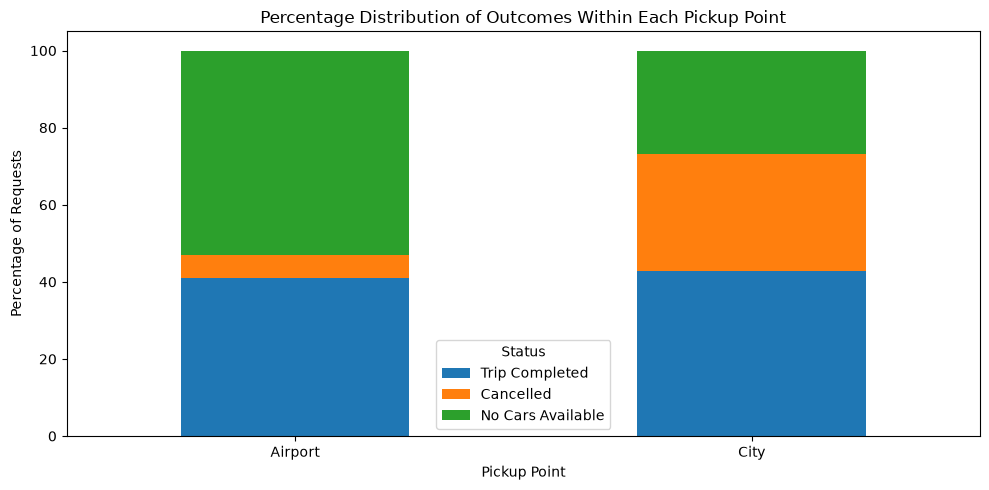

In [27]:
# Chart - 7: Failure type by pickup point
failure = pd.crosstab(df["Pickup point"], df["Status"], normalize="index") * 100
failure = failure[["Trip Completed", "Cancelled", "No Cars Available"]]
ax = failure.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Percentage Distribution of Outcomes Within Each Pickup Point")
ax.set_xlabel("Pickup Point")
ax.set_ylabel("Percentage of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Percentages make the two pickup locations comparable even though their total request counts differ.

##### 2. What is/are the insight(s) found from the chart?

The Airport has a much larger share of No Cars Available requests, while the City has a much larger cancellation share. Completed-trip shares are relatively similar.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Location-specific KPIs are more useful than one overall cancellation/failure rate because the operational cause differs by location.

#### Chart - 8

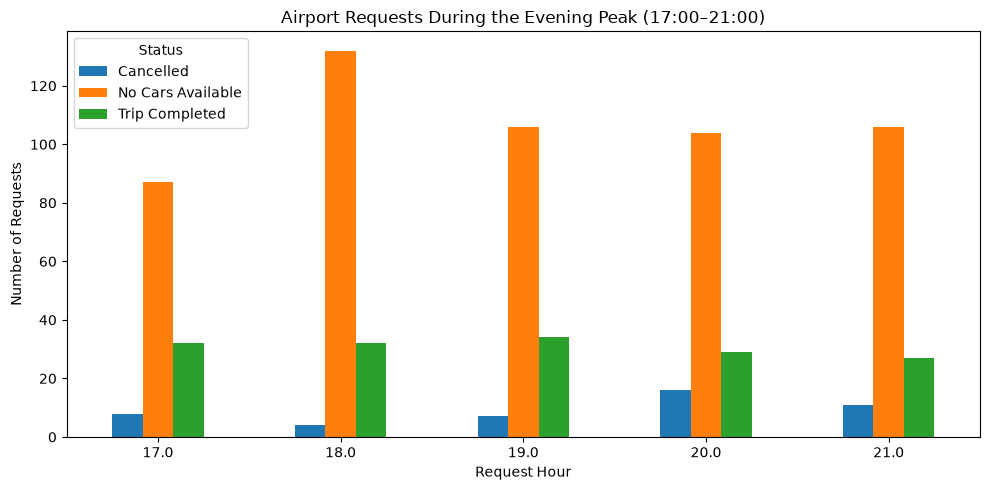

In [28]:
# Chart - 8: Airport evening shortage
airport_evening = (
    df[(df["Pickup point"] == "Airport") & (df["Request hour"].between(17, 21))]
    .groupby(["Request hour", "Status"]).size().unstack(fill_value=0)
)
ax = airport_evening.plot(kind="bar", figsize=(10, 5))
ax.set_title("Airport Requests During the Evening Peak (17:00–21:00)")
ax.set_xlabel("Request Hour")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The Airport evening window is the strongest concentration of supply-related failures, so it deserves a focused view.

##### 2. What is/are the insight(s) found from the chart?

No Cars Available dominates Airport outcomes from 17:00–21:00, with the largest count at 18:00. This is the clearest evidence of an evening Airport supply shortage.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Uber can pre-position drivers near the Airport before 17:00 and offer targeted peak-hour incentives to reduce unserved demand.

#### Chart - 9

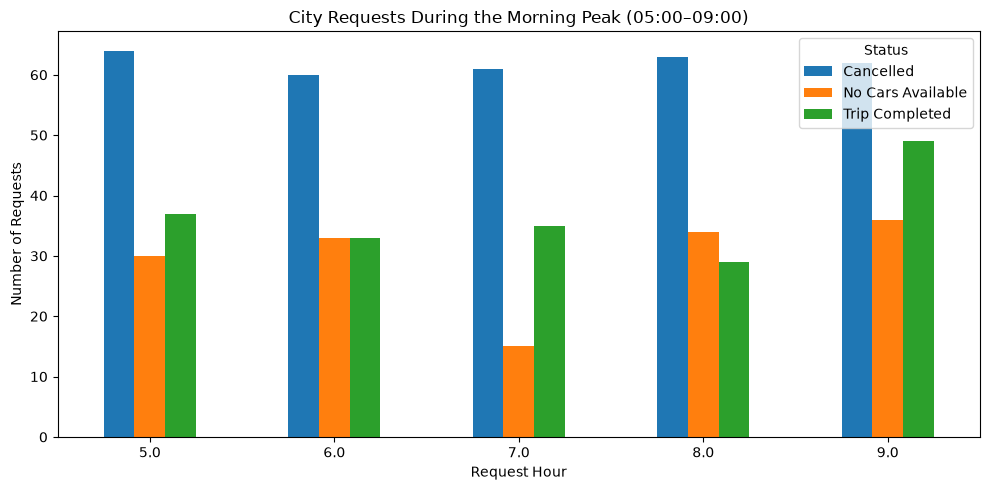

In [29]:
# Chart - 9: City morning cancellations
city_morning = (
    df[(df["Pickup point"] == "City") & (df["Request hour"].between(5, 9))]
    .groupby(["Request hour", "Status"]).size().unstack(fill_value=0)
)
ax = city_morning.plot(kind="bar", figsize=(10, 5))
ax.set_title("City Requests During the Morning Peak (05:00–09:00)")
ax.set_xlabel("Request Hour")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The City morning period is where cancellations are concentrated, so separating it from the rest of the day identifies a second operational problem.

##### 2. What is/are the insight(s) found from the chart?

Cancellations are particularly high between 05:00 and 09:00. The pattern is consistent with a morning commute toward the Airport and suggests that customers may cancel when the expected pickup experience is poor.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Better early-morning driver coverage, ETA accuracy, and proactive driver positioning can reduce cancellations and improve customer confidence.

#### Chart - 10

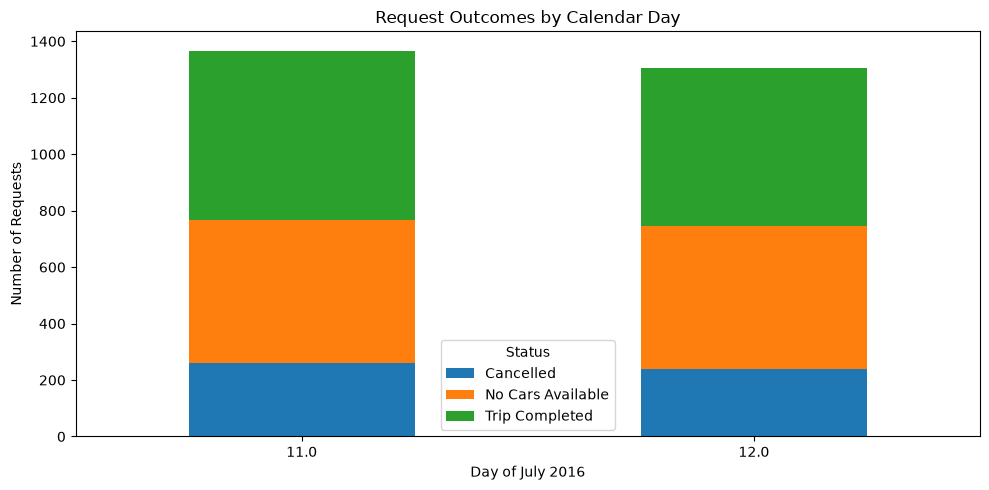

In [30]:
# Chart - 10: Requests by day and status
day_status = pd.crosstab(df["Request day"], df["Status"])
ax = day_status.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Request Outcomes by Calendar Day")
ax.set_xlabel("Day of July 2016")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The dataset covers five consecutive days, so day-level comparison checks whether the problem is isolated to one date.

##### 2. What is/are the insight(s) found from the chart?

Request volumes and failure counts vary by day, but the main status categories occur throughout the period. The operational problem is therefore not limited to a single unusual day.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Since the patterns recur, scheduling rules and driver incentives can be built into regular operations rather than treated as one-off responses.

#### Chart - 11

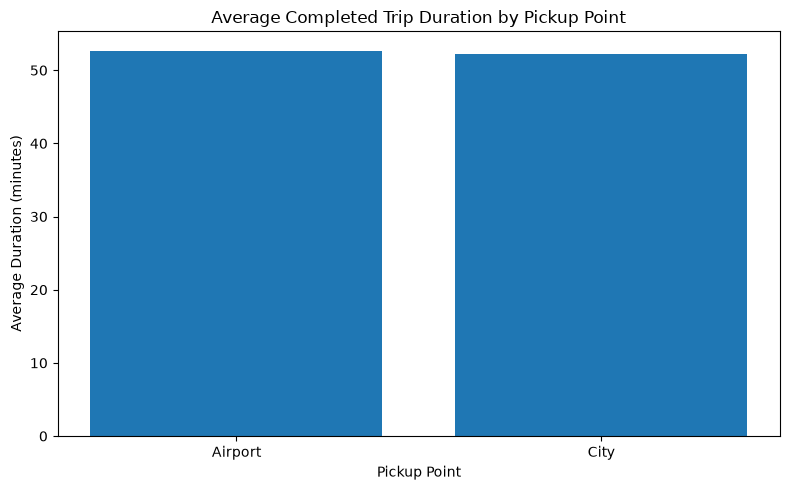

Overall average completed-trip duration: 52.47 minutes


In [31]:
# Chart - 11: Average trip duration
duration_summary = df.loc[df["Status"] == "Trip Completed"].groupby("Pickup point")["Trip duration (min)"].mean()
plt.figure(figsize=(8, 5))
plt.bar(duration_summary.index, duration_summary.values)
plt.title("Average Completed Trip Duration by Pickup Point")
plt.xlabel("Pickup Point")
plt.ylabel("Average Duration (minutes)")
plt.tight_layout()
plt.show()

print("Overall average completed-trip duration:",
      round(df.loc[df["Status"] == "Trip Completed", "Trip duration (min)"].mean(), 2),
      "minutes")

##### 1. Why did you pick the specific chart?

Average duration provides operational context for how long a driver remains occupied after accepting a request.

##### 2. What is/are the insight(s) found from the chart?

Completed trips average about 52.4 minutes overall. Airport and City trips have similar but not identical average durations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Because completed rides keep drivers occupied for roughly an hour, supply planning must account for driver turnaround time during peaks rather than simply matching the number of requests at the current minute.

#### Chart - 12

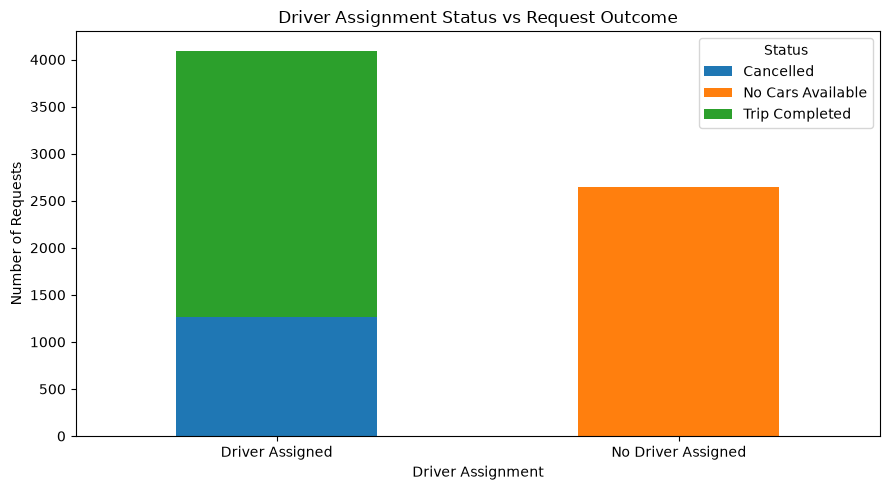

In [32]:
# Chart - 12: Driver assignments vs request outcomes
driver_assignment = df["Driver id"].notna().map({True: "Driver Assigned", False: "No Driver Assigned"})
assignment_status = pd.crosstab(driver_assignment, df["Status"])
ax = assignment_status.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_title("Driver Assignment Status vs Request Outcome")
ax.set_xlabel("Driver Assignment")
ax.set_ylabel("Number of Requests")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Driver assignment is directly connected to the service-supply problem and provides a useful validation of the missing Driver ID interpretation.

##### 2. What is/are the insight(s) found from the chart?

Requests with missing Driver IDs correspond to the No Cars Available outcome, while completed and cancelled requests have assigned drivers. This confirms that missing Driver IDs are meaningful operational records rather than arbitrary missing data.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

Supply KPIs should track driver assignment separately from cancellation. Increasing the share of requests that receive a driver is the most direct lever for reducing the largest failure category.

#### Chart - 13

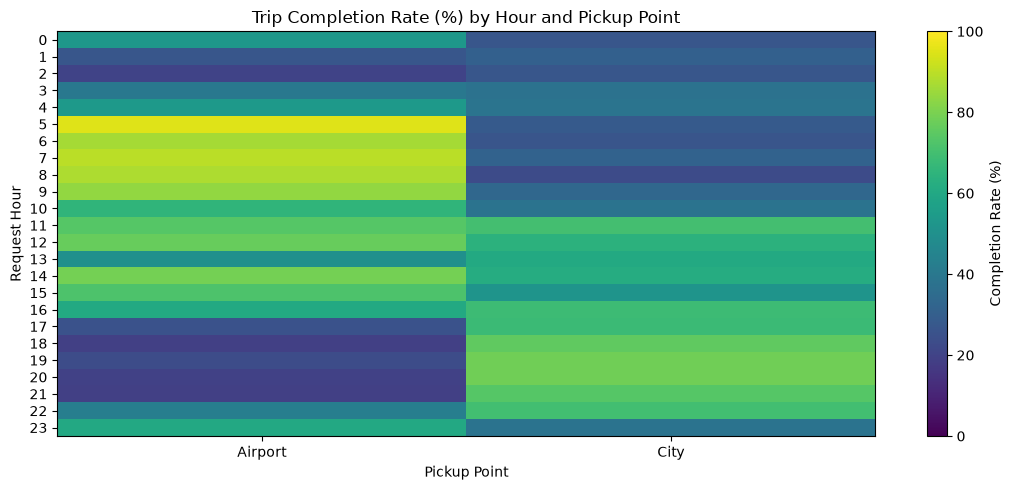

In [33]:
# Chart - 13: Completion rate by pickup point and hour
completion_pivot = (
    df.pivot_table(index="Request hour", columns="Pickup point",
                   values="Completed", aggfunc="mean") * 100
)
plt.figure(figsize=(11, 5))
plt.imshow(completion_pivot.values, aspect="auto", vmin=0, vmax=100)
plt.colorbar(label="Completion Rate (%)")
plt.title("Trip Completion Rate (%) by Hour and Pickup Point")
plt.xlabel("Pickup Point")
plt.ylabel("Request Hour")
plt.xticks(range(len(completion_pivot.columns)), completion_pivot.columns)
plt.yticks(range(24), range(24))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This heatmap combines the two strongest dimensions in the dataset—time and pickup location—and shows where service quality is weakest.

##### 2. What is/are the insight(s) found from the chart?

Airport completion deteriorates strongly during the evening, while City completion is weakest during parts of the morning peak. The combined view confirms that operational interventions should be directional and time-specific.

##### 3. Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

A single fleet rule is unlikely to solve the problem. A time-and-location dispatch strategy can target the cells with the lowest completion rates and highest business risk.

#### Chart - 14 - Correlation Heatmap

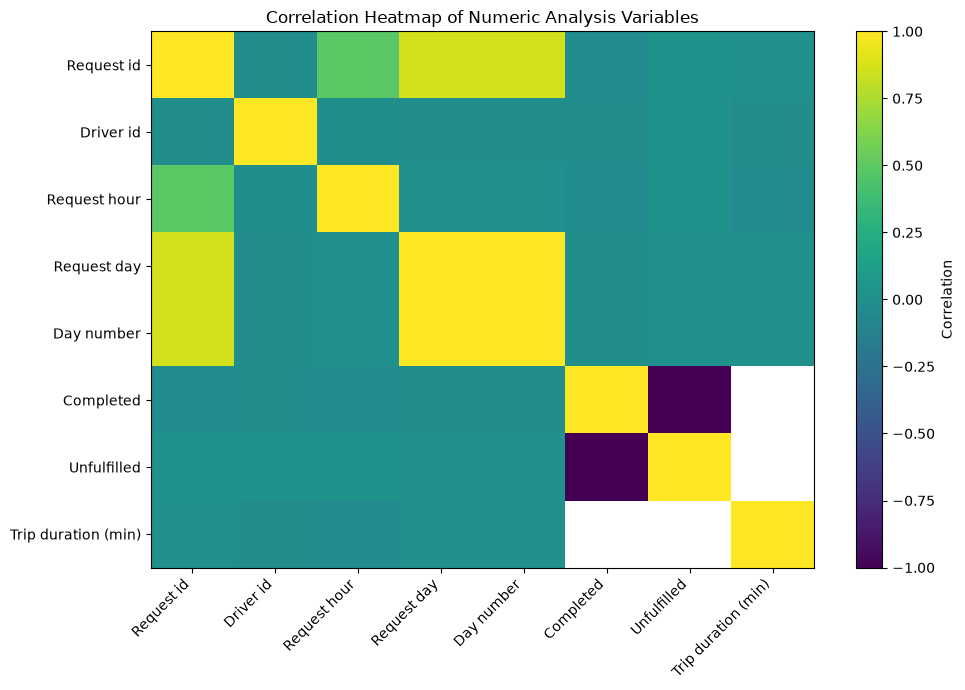

In [34]:
# Correlation Heatmap visualization code
numeric_cols = [
    "Request id", "Driver id", "Request hour", "Request day",
    "Day number", "Completed", "Unfulfilled", "Trip duration (min)"
]
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap of Numeric Analysis Variables")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap summarizes linear relationships among the numeric variables created during data preparation. It is useful as a compact diagnostic before drawing conclusions from individual variables.

##### 1. Why did you pick the specific chart?

A correlation heatmap summarizes linear relationships among the numeric variables created during data preparation. It is useful as a compact diagnostic before drawing conclusions from individual variables.

##### 2. What is/are the insight(s) found from the chart?

The strongest relationships are driven by the way business indicators are constructed. `Completed` and `Unfulfilled` are complementary indicators, so they show a strong negative relationship. Driver assignment is also closely associated with request outcome. The time variables have weaker direct linear relationships with completion, supporting the use of time-and-location visualizations for the main operational conclusions.

#### Chart - 15 - Pair Plot

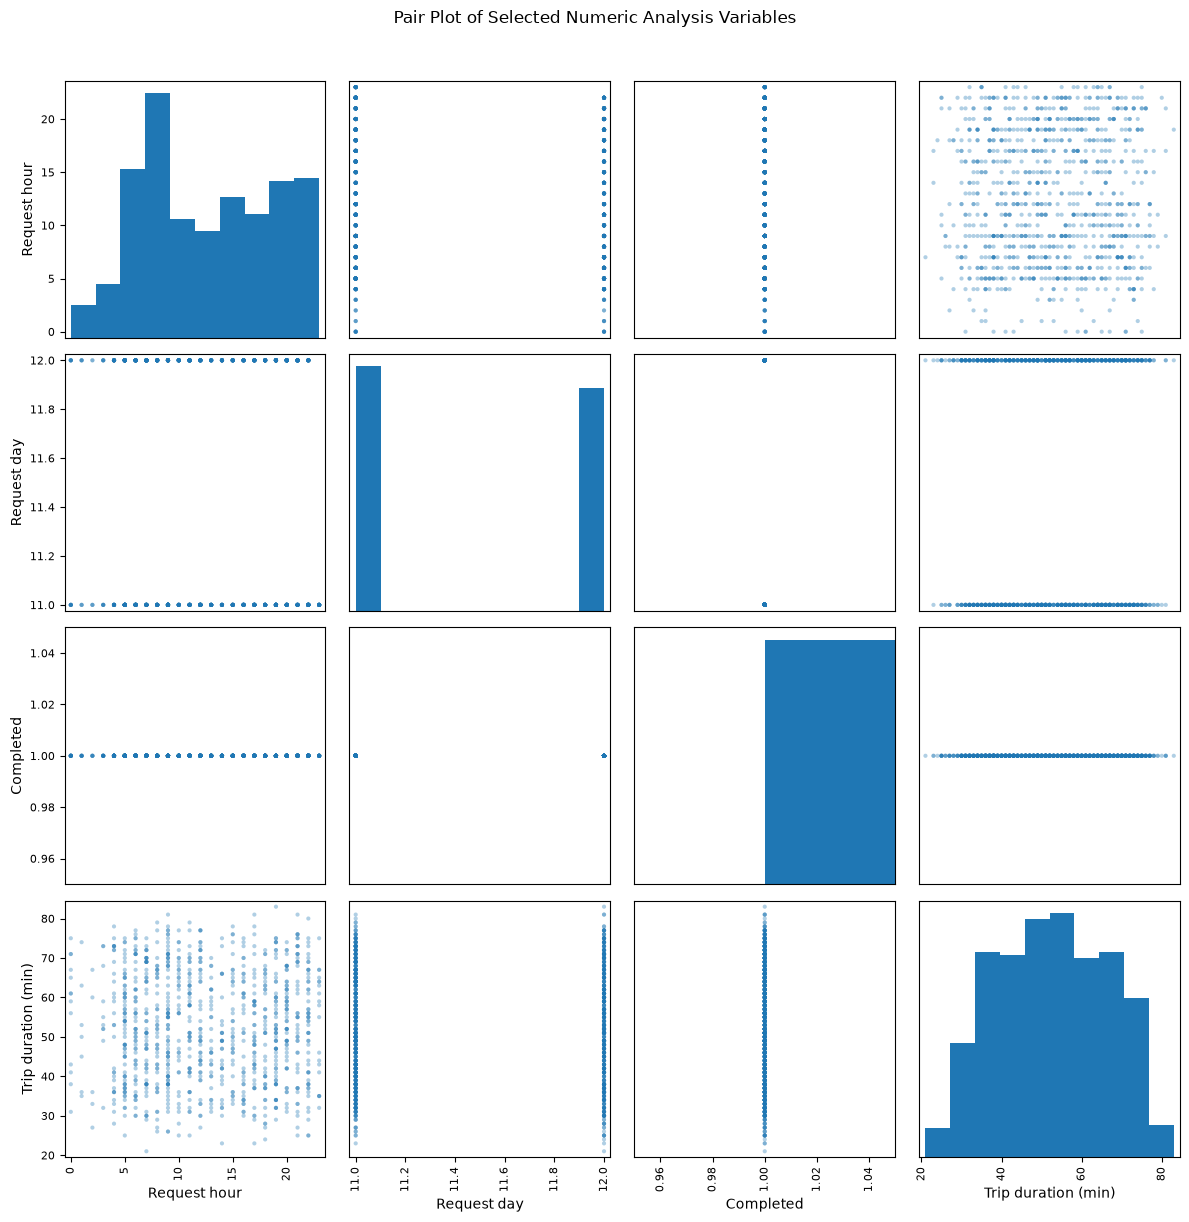

In [35]:
# Pair Plot visualization code
pair_cols = ["Request hour", "Request day", "Completed", "Trip duration (min)"]
pair_data = df[pair_cols].dropna()
sample = pair_data.sample(min(1000, len(pair_data)), random_state=42)

axes = scatter_matrix(sample, figsize=(12, 12), diagonal="hist", alpha=0.35)
plt.suptitle("Pair Plot of Selected Numeric Analysis Variables", y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot provides a compact view of distributions and pairwise relationships among request hour, request day, completion and trip duration. A controlled sample keeps the notebook responsive.

##### 1. Why did you pick the specific chart?

A pair plot provides a compact view of distributions and pairwise relationships among request hour, request day, completion and trip duration. A controlled sample is used so the notebook remains responsive.

##### 2. What is/are the insight(s) found from the chart?

The variables do not show one simple linear relationship that explains request success. Instead, the time-by-location analysis is more informative: request outcomes change materially by hour and pickup point. Trip duration is only observed for completed trips, so it should not be interpreted as a causal driver of completion.

The pair plot is primarily a diagnostic visualization; the strongest business conclusions come from the status, time and pickup-point analyses above.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

### Recommended solution to the Business Objective

1. **Increase Airport supply before and during 17:00–21:00.** This is the clearest “No Cars Available” peak. Use targeted incentives, driver staging and proactive repositioning.
2. **Protect the early-morning City-to-Airport flow (05:00–09:00).** Increase scheduled availability and improve estimated pickup times to reduce customer cancellations.
3. **Use time-and-location based driver allocation.** The demand pattern is directional: City demand is stronger in the morning, while Airport demand is stronger in the evening.
4. **Track failure types separately.** `No Cars Available` is primarily a supply problem, while `Cancelled` needs customer-experience and reliability interventions.
5. **Monitor completion rate as the primary service KPI.** Overall completion is only about **41.97%**, so moving even a portion of failed requests into completed trips can materially improve service utilization and customer satisfaction.
6. **Build a recurring peak-period dashboard.** Track requests, completion rate, no-car rate and cancellation rate by pickup point and hour so operations teams can adjust driver positioning continuously.

The key recommendation is not simply to add more drivers; it is to place the available driver capacity where and when the data shows the largest supply-demand mismatch.

# **Conclusion**

## Conclusion

The Uber Request Data shows a clear service-capacity problem: only **2,831 of 6,745 requests (41.97%)** were completed, while **2,650 (39.29%)** received the status **No Cars Available** and **1,264 (18.74%)** were cancelled. The largest opportunity is therefore to improve driver availability rather than focusing only on cancellations.

The problem is highly dependent on time and pickup location. Airport requests experience a pronounced shortage of cars during the evening peak, especially around **17:00–21:00**, while City requests show a high concentration of cancellations during the **05:00–09:00** morning period. This pattern is consistent with directional commuter demand between the City and Airport.

The analysis also shows that completed trips take about **52.4 minutes on average**, meaning driver capacity is occupied for a meaningful period after each successful assignment. Uber should therefore use proactive driver positioning and targeted peak-hour incentives instead of relying only on reactive dispatching.

Overall, the most effective business strategy is a **time- and location-aware supply allocation model**: increase Airport availability before the evening rush, strengthen City availability before the morning Airport commute, and monitor the two failure categories separately. This approach can improve the completion rate, reduce lost requests, make better use of the existing driver fleet, and improve customer experience.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***